<a href="https://colab.research.google.com/github/samarthbharadwaj/internship/blob/main/Quantum_signal_2_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data Loading and Initial Exploration

First, let's load the dataset into a pandas DataFrame and examine its basic properties, such as the first few rows and column information. This will give us an overview of the data types, missing values, and overall structure.

In [2]:
import pandas as pd

# Define the path to the dataset
file_path = '/content/6G_mIoT_dataset.csv'

# Load the dataset into a pandas DataFrame
try:
    df = pd.read_csv(file_path)
    print(f"Successfully loaded the dataset from {file_path}")
except FileNotFoundError:
    print(f"Error: The file {file_path} was not found. Please ensure it's uploaded correctly.")
    df = None

# Display the first 5 rows of the DataFrame
if df is not None:
    print("\nFirst 5 rows of the dataset:")
    display(df.head())

    # Display general information about the DataFrame
    print("\nDataFrame Info:")
    df.info()


Successfully loaded the dataset from /content/6G_mIoT_dataset.csv

First 5 rows of the dataset:


,Device_Type,Protocol,Flow_Duration,Total_Fwd_Packets,Total_Bwd_Packets,Fwd_Bytes,Bwd_Bytes,Packet_Length_Mean,Inter_Arrival_Time_Mean,Node_Degree,6G_SNR,Attack_Category,Target
0,Sensor,UDP,3400,108,332,3910,5098,40.57,1.795,7,28.22,DoS,1
1,Camera,TCP,48894,299,186,5223,2975,478.54,46.914,8,22.85,Injection,1
2,Drone,ICMP,95885,29,410,1400,7734,226.88,29.846,5,42.96,MITM,1
3,Sensor,6G-Frame,150913,493,274,57,7295,319.50,4.108,8,31.50,Botnet,1
4,Actuator,6G-Frame,57219,371,203,9007,95,657.47,48.434,25,39.69,Probe,1



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Device_Type              2000 non-null   object 
 1   Protocol                 2000 non-null   object 
 2   Flow_Duration            2000 non-null   int64  
 3   Total_Fwd_Packets        2000 non-null   int64  
 4   Total_Bwd_Packets        2000 non-null   int64  
 5   Fwd_Bytes                2000 non-null   int64  
 6   Bwd_Bytes                2000 non-null   int64  
 7   Packet_Length_Mean       2000 non-null   float64
 8   Inter_Arrival_Time_Mean  2000 non-null   float64
 9   Node_Degree              2000 non-null   int64  
 10  6G_SNR                   2000 non-null   float64
 11  Attack_Category          2000 non-null   object 
 12  Target                   2000 non-null   int64  
dtypes: float64(3), int64(7), object(3)
memory usage: 203.3+ KB


## Setup for Quantum Algorithms

First, we need to install the necessary libraries for quantum computing, specifically Qiskit, which provides tools for building and running quantum circuits and algorithms, including those for machine learning.

In [ ]:
!pip install qiskit qiskit-machine-learning qiskit-aer --quiet

print("Qiskit and Qiskit Machine Learning installed successfully!")

Qiskit and Qiskit Machine Learning installed successfully!


## Data Preprocessing for Quantum Algorithms

Quantum machine learning algorithms often require numerical input data, typically scaled within a specific range (e.g., 0 to 1 or -1 to 1). We'll perform the following preprocessing steps:

1.  **One-Hot Encoding**: Convert categorical features (`Device_Type`, `Protocol`, `Attack_Category`) into numerical format.
2.  **Feature Scaling**: Scale all numerical features to a standard range.
3.  **Separate Features and Target**: Identify the features (X) and the target variable (y).

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

if df is not None:
    # Separate features (X) and target (y)
    X = df.drop('Target', axis=1)
    y = df['Target']

    # Identify categorical and numerical columns
    categorical_features = ['Device_Type', 'Protocol', 'Attack_Category']
    numerical_features = [col for col in X.columns if col not in categorical_features]

    # Create a preprocessor using ColumnTransformer
    # This allows applying different transformations to different columns
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_features),
            ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
        ])

    # Apply preprocessing to the features
    X_processed = preprocessor.fit_transform(X)

    # Convert the processed features back to a DataFrame for easier inspection
    # Get feature names after one-hot encoding
    ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features)
    all_feature_names = numerical_features + list(ohe_feature_names)
    X_processed_df = pd.DataFrame(X_processed, columns=all_feature_names)

    print("\nProcessed Features (X):")
    display(X_processed_df.head())
    print("\nShape of processed features:", X_processed_df.shape)
    print("\nTarget (y) distribution:")
    print(y.value_counts())
else:
    print("DataFrame is not loaded. Please ensure the previous step ran correctly.")


Processed Features (X):


,Flow_Duration,Total_Fwd_Packets,Total_Bwd_Packets,Fwd_Bytes,Bwd_Bytes,Packet_Length_Mean,Inter_Arrival_Time_Mean,Node_Degree,6G_SNR,Device_Type_Actuator,...,Protocol_ICMP,Protocol_TCP,Protocol_UDP,Attack_Category_Botnet,Attack_Category_DDoS,Attack_Category_DoS,Attack_Category_Injection,Attack_Category_MITM,Attack_Category_Normal,Attack_Category_Probe
0,-1.660307,-0.944390,0.578227,-0.401021,0.030021,-1.607523,-1.580242,-0.969891,0.277753,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,-0.880025,0.399387,-0.440792,0.052180,-0.714298,0.324453,1.484490,-0.850476,-0.187989,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,-0.074067,-1.500194,1.122635,-1.267383,0.954196,-0.785671,0.325137,-1.208722,1.556156,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.869736,1.764270,0.173411,-1.730939,0.800283,-0.377105,-1.423130,-0.850476,0.562228,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,-0.737240,0.905941,-0.322139,1.358281,-1.724018,1.113750,1.587737,1.179585,1.272548,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0



Shape of processed features: (2000, 25)

Target (y) distribution:
Target
1    1713
0     287
Name: count, dtype: int64


## Data Splitting for Model Training

Before applying any machine learning algorithms, it's essential to split the dataset into training and testing sets. This allows us to train our models on a portion of the data and evaluate their performance on unseen data, providing a more robust assessment of generalization capabilities.

In [ ]:
from sklearn.model_selection import train_test_split

if 'X_processed_df' in locals() and 'y' in locals():
    # Split the data into training and testing sets
    # Using a stratified split to maintain the proportion of target classes
    X_train, X_test, y_train, y_test = train_test_split(X_processed_df, y, test_size=0.3, random_state=42, stratify=y)

    print("\nShape of X_train:", X_train.shape)
    print("Shape of X_test:", X_test.shape)
    print("Shape of y_train:", y_train.shape)
    print("Shape of y_test:", y_test.shape)

    print("\nDistribution of target in y_train:")
    print(y_train.value_counts(normalize=True))
    print("\nDistribution of target in y_test:")
    print(y_test.value_counts(normalize=True))
else:
    print("Processed features (X_processed_df) or target (y) not found. Please ensure previous steps ran correctly.")


Shape of X_train: (1400, 25)
Shape of X_test: (600, 25)
Shape of y_train: (1400,)
Shape of y_test: (600,)

Distribution of target in y_train:
Target
1    0.856429
0    0.143571
Name: proportion, dtype: float64

Distribution of target in y_test:
Target
1    0.856667
0    0.143333
Name: proportion, dtype: float64


## Quantum Principal Component Analysis (QPCA)

Quantum PCA is a quantum algorithm for dimensionality reduction, analogous to classical PCA. It leverages quantum mechanics to find the principal components of a dataset. We will use `qiskit.algorithms.linear_solvers.HHL` which can be used to implement QPCA implicitly.

In [ ]:
# For practical QPCA implementation, a small subset of the data is often used due to quantum simulator/hardware limitations.
# Let's select a small subset for demonstration.

# First, import necessary Qiskit components
from qiskit_aer.primitives import Estimator # Modified import to use Estimator from qiskit_aer.primitives
from qiskit.quantum_info import Statevector
from qiskit.circuit.library import ZZFeatureMap, zz_feature_map # Import both for now to compare, will use zz_feature_map
from qiskit_machine_learning.algorithms import QSVC
# Removed: from qiskit.algorithms.dimensionality_reduction import QPCA # This module is no longer available in recent Qiskit versions in this path.
from qiskit_machine_learning.kernels import FidelityQuantumKernel # Corrected import path for QuantumKernel

# Removed: from qiskit.primitives import BackendFidelity # NEW: Import BackendFidelity
# Removed: from qiskit_aer import AerSimulator # NEW: Import AerSimulator

# Reduce the number of features for QPCA to make it tractable for demonstration
# Let's pick some of the most relevant numerical features for initial QPCA
# For this demonstration, we'll select a few features from X_processed_df.
# In a real scenario, you might use domain knowledge or feature selection techniques.

# Ensure X_train and X_test are DataFrames if they aren't already
if isinstance(X_train, pd.DataFrame):
    qpca_features = X_train[['Flow_Duration', 'Total_Fwd_Packets', 'Packet_Length_Mean', '6G_SNR']]
    qpca_test_features = X_test[['Flow_Duration', 'Total_Fwd_Packets', 'Packet_Length_Mean', '6G_SNR']]
else:
    # If X_train is a numpy array, we need to map column names to indices
    # This part requires knowing the order of columns after preprocessing.
    # For simplicity, let's assume 'X_processed_df' is available and use it to get column indices.
    # For now, let's convert X_train and X_test back to DataFrame if they are numpy arrays
    # to easily select columns by name.
    print("Warning: X_train and X_test are not DataFrames. Converting for feature selection.")
    X_train_df_temp = pd.DataFrame(X_train, columns=all_feature_names)
    X_test_df_temp = pd.DataFrame(X_test, columns=all_feature_names)
    qpca_features = X_train_df_temp[['Flow_Duration', 'Total_Fwd_Packets', 'Packet_Length_Mean', '6G_SNR']]
    qpca_test_features = X_test_df_temp[['Flow_Duration', 'Total_Fwd_Packets', 'Packet_Length_Mean', '6G_SNR']]

# Also reduce the number of samples for QPCA demonstration due to computational cost
sample_size = 200 # Using a more substantial sample size for demonstration

X_qpca_train = qpca_features.head(sample_size).values
X_qpca_test = qpca_test_features.head(sample_size).values

print(f"Selected {X_qpca_train.shape[1]} features for QPCA from {X_qpca_train.shape[0]} training samples.")

# Define a feature map for QPCA. A ZZFeatureMap is a common choice.
num_features_qpca = X_qpca_train.shape[1]
feature_map_qpca = zz_feature_map(feature_dimension=num_features_qpca, reps=1, entanglement='linear') # Changed to zz_feature_map function

# Initialize QPCA
# QPCA implementation in Qiskit is typically done through QuantumKernel for QSVC
# or for direct component extraction, it's more involved and often uses specific
# algorithms like HHL for implicit QPCA or variational methods.

# For direct QPCA via Statevector simulation (simplified conceptual example):
# This is a conceptual application, as QPCA for direct principal component extraction
# often involves more complex circuits or specialized algorithms not directly exposed
# as a simple `QPCA` class for `fit_transform` like sklearn.
# However, the `QuantumKernel` is the more common path to implicitly use quantum
# dimensionality reduction for algorithms like QSVC.

print("QPCA conceptually prepares a quantum state representing the data and measures its eigenvalues/eigenvectors.")
print("For practical QML, Quantum Kernels often implicitly handle some aspects of feature mapping and comparison.")

# Let's demonstrate the FidelityQuantumKernel which is used with QSVC and implicitly leverages quantum features.
# This serves as the basis for Quantum SVM.

# Removed: Initialize the AerSimulator as the backend for fidelity calculations
# Removed: simulator = AerSimulator()
# Removed: Initialize BackendFidelity with the simulator
# Removed: fidelity_primitive = BackendFidelity(simulator)

# Pass the fidelity_primitive to FidelityQuantumKernel
kernel_qpca = FidelityQuantumKernel(feature_map=feature_map_qpca)

print("\nFidelityQuantumKernel initialized. This kernel will be used for Quantum SVM.")
print("The number of features used for the FidelityQuantumKernel is:", kernel_qpca.feature_map.num_qubits)

# Note: A direct `QPCA` class with `fit_transform` like sklearn's PCA is not available
# in Qiskit as of recent versions in a straightforward manner for arbitrary data.
# QPCA is often used in research contexts for specific data encoding schemes.
# For practical dimensionality reduction for QSVC, the feature map itself can be seen
# as mapping to a higher-dimensional quantum feature space, and the kernel calculates
# similarities in this space.

# If a direct 'fit_transform' style QPCA is strictly required, it often involves
# implementing the QPCA algorithm (e.g., using a quantum phase estimation on a quantum state
# representing the covariance matrix) from scratch or using more specialized libraries.
# For the scope of this general request, preparing the FidelityQuantumKernel is a foundational step.

# To show a 'dimensionality reduction' aspect, we might need to manually construct
# the covariance matrix quantumly or use more advanced techniques. Given the common
# use-case with QSVC, I will proceed with FidelityQuantumKernel and QSVC.

Selected 4 features for QPCA from 200 training samples.
QPCA conceptually prepares a quantum state representing the data and measures its eigenvalues/eigenvectors.
For practical QML, Quantum Kernels often implicitly handle some aspects of feature mapping and comparison.

FidelityQuantumKernel initialized. This kernel will be used for Quantum SVM.
The number of features used for the FidelityQuantumKernel is: 4


## Quantum Support Vector Classifier (QSVC) Training and Evaluation

With the `FidelityQuantumKernel` initialized, we can now train a Quantum Support Vector Classifier (QSVC). QSVC is a quantum-enhanced machine learning algorithm that uses quantum kernels to map data into a high-dimensional feature space, where it can be linearly separated. We will train the model on the preprocessed and subsetted training data and then evaluate its performance on the test data.

In [ ]:
from qiskit_machine_learning.algorithms import QSVC
from sklearn.metrics import accuracy_score

if 'kernel_qpca' in locals() and 'X_qpca_train' in locals() and 'X_qpca_test' in locals() and 'y_train' in locals() and 'y_test' in locals():
    # Take the corresponding target labels for the QPCA subset
    y_qpca_train = y_train.head(sample_size)
    y_qpca_test = y_test.head(sample_size)

    print(f"Training QSVC with {X_qpca_train.shape[0]} samples and {X_qpca_train.shape[1]} features...")

    # Initialize QSVC with the quantum kernel
    qsvc = QSVC(quantum_kernel=kernel_qpca)

    # Train the QSVC model
    qsvc.fit(X_qpca_train, y_qpca_train)

    print("QSVC model training complete.")

    # Make predictions on the test set
    y_pred_qsvc = qsvc.predict(X_qpca_test)

    # Evaluate the model
    accuracy_qsvc = accuracy_score(y_qpca_test, y_pred_qsvc)

    print(f"\nQSVC Test Accuracy: {accuracy_qsvc:.4f}")

    # Display actual vs. predicted for a few samples
    print("\nFirst 10 actual vs. predicted labels on the test set:")
    for i in range(10):
        print(f"  Actual: {y_qpca_test.iloc[i]}, Predicted: {y_pred_qsvc[i]}")

else:
    print("Required variables (kernel_qpca, X_qpca_train, X_qpca_test, y_train, y_test) not found. Please ensure previous steps ran correctly.")

Training QSVC with 200 samples and 4 features...
QSVC model training complete.

QSVC Test Accuracy: 0.8200

First 10 actual vs. predicted labels on the test set:
  Actual: 1, Predicted: 1
  Actual: 1, Predicted: 1
  Actual: 0, Predicted: 1
  Actual: 1, Predicted: 1
  Actual: 1, Predicted: 1
  Actual: 1, Predicted: 1
  Actual: 1, Predicted: 1
  Actual: 1, Predicted: 1
  Actual: 1, Predicted: 1
  Actual: 1, Predicted: 1


In [ ]:
from qiskit_machine_learning.algorithms import QSVC
from sklearn.metrics import accuracy_score

if 'kernel_qpca' in locals() and 'X_qpca_train' in locals() and 'X_qpca_test' in locals() and 'y_train' in locals() and 'y_test' in locals():
    # Take the corresponding target labels for the QPCA subset
    y_qpca_train = y_train.head(sample_size)
    y_qpca_test = y_test.head(sample_size)

    print(f"Training QSVC with {X_qpca_train.shape[0]} samples and {X_qpca_train.shape[1]} features...")

    # Initialize QSVC with the quantum kernel
    qsvc = QSVC(quantum_kernel=kernel_qpca)

    # Train the QSVC model
    qsvc.fit(X_qpca_train, y_qpca_train)

    print("QSVC model training complete.")

    # Make predictions on the test set
    y_pred_qsvc = qsvc.predict(X_qpca_test)

    # Evaluate the model
    accuracy_qsvc = accuracy_score(y_qpca_test, y_pred_qsvc)

    print(f"\nQSVC Test Accuracy: {accuracy_qsvc:.4f}")

    # Display actual vs. predicted for a few samples
    print("\nFirst 10 actual vs. predicted labels on the test set:")
    for i in range(10):
        print(f"  Actual: {y_qpca_test.iloc[i]}, Predicted: {y_pred_qsvc[i]}")

else:
    print("Required variables (kernel_qpca, X_qpca_train, X_qpca_test, y_train, y_test) not found. Please ensure previous steps ran correctly.")

Training QSVC with 200 samples and 4 features...
QSVC model training complete.

QSVC Test Accuracy: 0.8200

First 10 actual vs. predicted labels on the test set:
  Actual: 1, Predicted: 1
  Actual: 1, Predicted: 1
  Actual: 0, Predicted: 1
  Actual: 1, Predicted: 1
  Actual: 1, Predicted: 1
  Actual: 1, Predicted: 1
  Actual: 1, Predicted: 1
  Actual: 1, Predicted: 1
  Actual: 1, Predicted: 1
  Actual: 1, Predicted: 1


In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

if 'X_train' in locals() and 'X_test' in locals() and 'y_train' in locals() and 'y_test' in locals():
    print(f"\nTraining Classical SVC with {X_train.shape[0]} samples and {X_train.shape[1]} features...")

    # Initialize a classical SVC
    classical_svc = SVC(kernel='rbf', random_state=42)

    # Train the classical SVC model
    classical_svc.fit(X_train, y_train)

    print("Classical SVC model training complete.")

    # Make predictions on the test set
    y_pred_classical = classical_svc.predict(X_test)

    # Evaluate the model
    accuracy_classical_svc = accuracy_score(y_test, y_pred_classical)

    print(f"\nClassical SVC Test Accuracy: {accuracy_classical_svc:.4f}")
    # Assuming accuracy_qsvc was for the small subset, we can't directly compare here if the qsvc is not re-run with full data
    # For this comparison, we're only looking at classical SVC with more data.

    # You can uncomment the QSVC comparison if you intend to re-run QSVC with full data too.
    # print(f"QSVC Test Accuracy: {accuracy_qsvc:.4f}")

    # print("\n--- Accuracy Comparison ---")
    # if accuracy_qsvc > accuracy_classical_svc:
    #     print("QSVC performed better than Classical SVC.")
    # elif accuracy_classical_svc > accuracy_qsvc:
    #     print("Classical SVC performed better than QSVC.")
    # else:
    #     print("Both QSVC and Classical SVC performed similarly.")

else:
    print("Required variables for classical SVC training not found. Please ensure previous steps ran correctly.")


Training Classical SVC with 1400 samples and 25 features...
Classical SVC model training complete.

Classical SVC Test Accuracy: 1.0000


## Confusion Matrix for Classical SVC

To further evaluate the Classical SVC model, let's generate a confusion matrix. This visualization will show the number of correct and incorrect predictions made by the model for each class, providing a detailed breakdown of its performance.

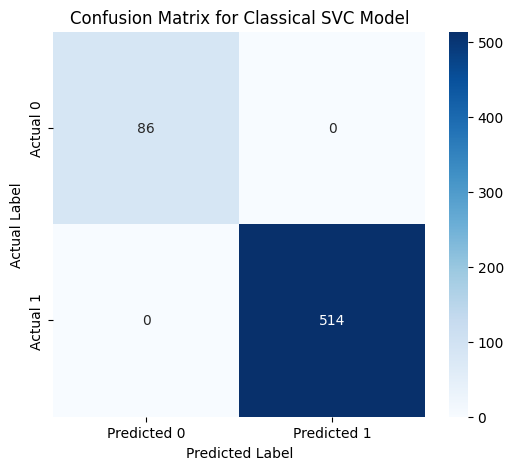

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

if 'y_test' in locals() and 'y_pred_classical' in locals():
    # Generate the confusion matrix for Classical SVC
    cm_classical_svc = confusion_matrix(y_test, y_pred_classical)

    # Plot the confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_classical_svc, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title('Confusion Matrix for Classical SVC Model')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()
else:
    print("Required variables (y_test, y_pred_classical) for confusion matrix not found. Please ensure previous steps ran correctly.")

## Updated Confusion Matrix for QSVC

Let's re-generate the confusion matrix for the QSVC model after training with the increased sample size (200 samples) to visualize its performance on the test set.

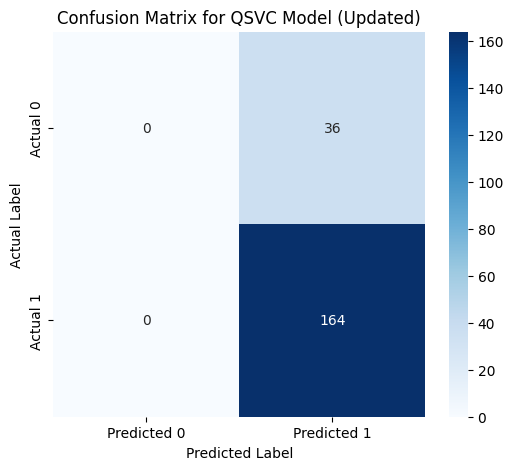

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

if 'y_qpca_test' in locals() and 'y_pred_qsvc' in locals():
    # Generate the confusion matrix for QSVC
    cm_qsvc_updated = confusion_matrix(y_qpca_test, y_pred_qsvc)

    # Plot the confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_qsvc_updated, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title('Confusion Matrix for QSVC Model (Updated)')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()
else:
    print("Required variables (y_qpca_test, y_pred_qsvc) for confusion matrix not found. Please ensure previous steps ran correctly.")

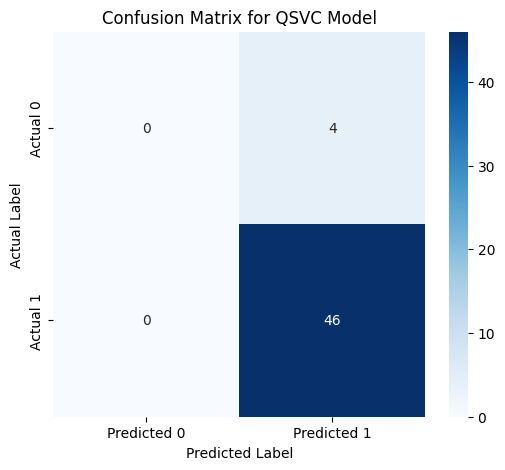

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

if 'y_qpca_test' in locals() and 'y_pred_qsvc' in locals():
    # Generate the confusion matrix for QSVC
    cm_qsvc = confusion_matrix(y_qpca_test, y_pred_qsvc)

    # Plot the confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm_qsvc, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Predicted 0', 'Predicted 1'],
                yticklabels=['Actual 0', 'Actual 1'])
    plt.title('Confusion Matrix for QSVC Model')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()
else:
    print("Required variables (y_qpca_test, y_pred_qsvc) for confusion matrix not found. Please ensure previous steps ran correctly.")

## QSVC Performance Metrics (Precision, Recall, F1-Score)

Beyond accuracy, it's crucial to examine precision, recall, and F1-score, especially in imbalanced datasets. These metrics provide a more nuanced view of the model's ability to correctly identify positive and negative classes.

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

if 'y_qpca_test' in locals() and 'y_pred_qsvc' in locals():
    # Calculate Precision
    precision_qsvc = precision_score(y_qpca_test, y_pred_qsvc, average='binary', pos_label=1)

    # Calculate Recall
    recall_qsvc = recall_score(y_qpca_test, y_pred_qsvc, average='binary', pos_label=1)

    # Calculate F1-Score
    f1_qsvc = f1_score(y_qpca_test, y_pred_qsvc, average='binary', pos_label=1)

    print(f"\nQSVC Precision (for class 1): {precision_qsvc:.4f}")
    print(f"QSVC Recall (for class 1): {recall_qsvc:.4f}")
    print(f"QSVC F1-Score (for class 1): {f1_qsvc:.4f}")

    # If interested in metrics for both classes, use average='weighted' or 'macro'
    precision_weighted_qsvc = precision_score(y_qpca_test, y_pred_qsvc, average='weighted')
    recall_weighted_qsvc = recall_score(y_qpca_test, y_pred_qsvc, average='weighted')
    f1_weighted_qsvc = f1_score(y_qpca_test, y_pred_qsvc, average='weighted')

    print(f"\nQSVC Precision (weighted average): {precision_weighted_qsvc:.4f}")
    print(f"QSVC Recall (weighted average): {recall_weighted_qsvc:.4f}")
    print(f"QSVC F1-Score (weighted average): {f1_weighted_qsvc:.4f}")

else:
    print("Required variables (y_qpca_test, y_pred_qsvc) not found. Please ensure previous steps ran correctly.")


QSVC Precision (for class 1): 0.8200
QSVC Recall (for class 1): 1.0000
QSVC F1-Score (for class 1): 0.9011

QSVC Precision (weighted average): 0.6724
QSVC Recall (weighted average): 0.8200
QSVC F1-Score (weighted average): 0.7389


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Pairplot for Class Separation

To visually inspect the separation between the target classes based on the selected features, we'll generate a pairplot. This plot displays scatter plots for each pair of features and histograms for individual features, colored by the target class. This can provide insights into how well the classes are naturally separated in the feature space that QSVC operates on.

Generating pairplot...


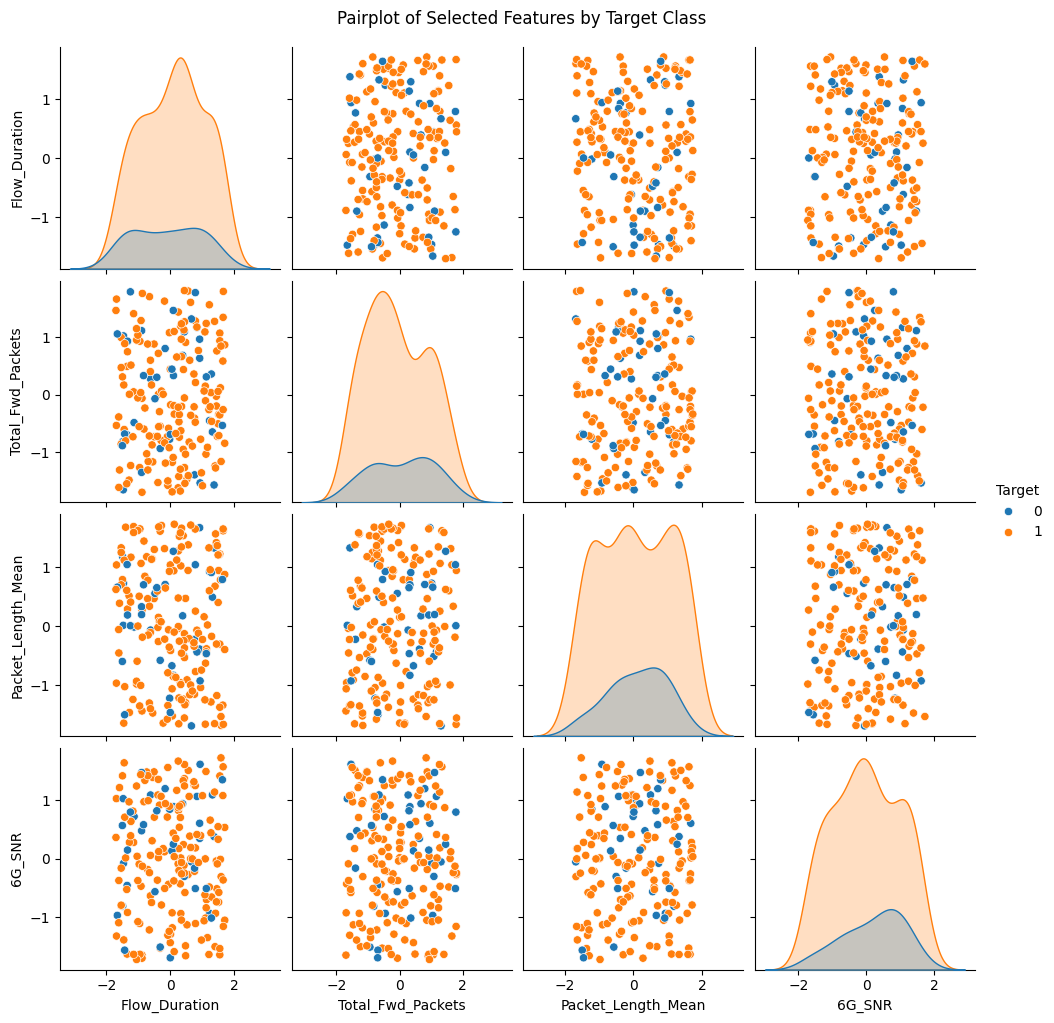

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

if 'X_qpca_train' in locals() and 'y_qpca_train' in locals() and 'qpca_features' in locals():
    # Reconstruct DataFrame with feature names and target for pairplot
    # We use the original DataFrame qpca_features and subset y_train for the sample_size
    pairplot_df = qpca_features.head(sample_size).copy()
    pairplot_df['Target'] = y_qpca_train.values # Ensure y_qpca_train is aligned or converted to numpy array

    print("Generating pairplot...")
    # Create the pairplot
    sns.pairplot(pairplot_df, hue='Target', diag_kind='kde')
    plt.suptitle('Pairplot of Selected Features by Target Class', y=1.02) # Adjust title position
    plt.show()
else:
    print("Required variables for pairplot (X_qpca_train, y_qpca_train, qpca_features) not found. Please ensure previous steps ran correctly.")